In [1]:
from libraries import *

/opt/miniconda3/envs/py310/bin/python


In [2]:
gp.setParam("OutputFlag", 0) # Disables Gurobi logs (Affects all models created afterward)

Set parameter Username
Set parameter LicenseID to value 2769212
Academic license - for non-commercial use only - expires 2027-01-22


      Time_s  Longitude_deg  Latitude_deg   Altitude_m
0        0.0     279.000000     49.000000  25000.00000
1      900.0     278.997982     49.018421  23951.48919
2     1800.0     278.991146     49.029046  23678.70919
5     2700.0     278.982578     49.035804  23675.55769
6     3600.0     278.974006     49.042329  23672.57558
..       ...            ...           ...          ...
182  82800.0     279.593425     49.128661  24030.70810
185  83700.0     279.604025     49.134353  24032.65500
186  84600.0     279.612554     49.141021  24030.74921
189  85500.0     279.620485     49.147937  24029.72337
190  86400.0     279.627055     49.155538  24350.33468

[97 rows x 4 columns]
⏱️ Calculating K_MAX from t=0 to t=95
[INFO] Loaded checkpoint from K_MAX_checkpoint.pkl
✅ Requested interval fully covered.


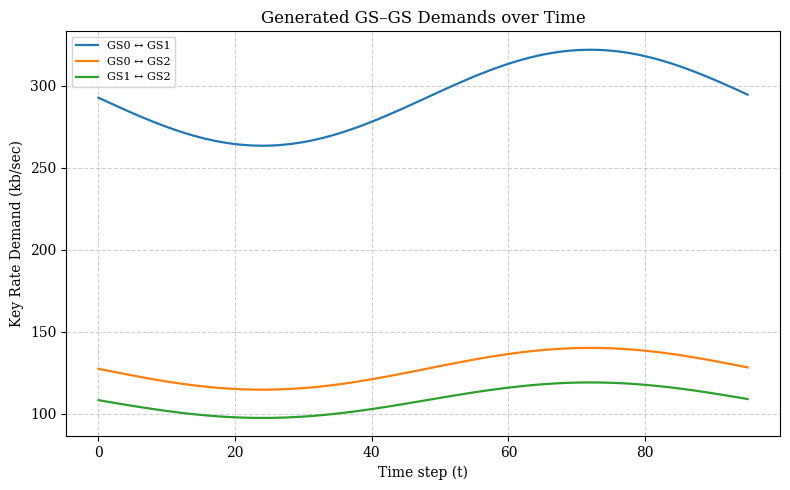

In [3]:
prob = 2
gnodes, hnodes, links, demands = init_setup_real_online(prob)

nodes = gnodes + hnodes

In [4]:
# Initialize state and action
state  = [{} for _ in syst.T]
action = [{} for _ in syst.T]
reward = [0  for _ in syst.T]

state[0]["demands"] = demands
state[0]["a"] = {i: 0 for i in range(len(links))}

In [5]:
# ---------- Hyperparams ----------
# GAMMA = 0.99
# GAE_LAMBDA = 0.95
# CLIP = 0.2
# LR = 3e-4
# EPOCHS = 4
# BATCH_SIZE = 64
# ENTROPY_COEF_INITIAL = 0.05         # >>> CHANGE - will decay over training
# ENTROPY_COEF_MIN = 0.001            # >>> CHANGE
# ENTROPY_DECAY = 0.995               # >>> CHANGE
# VALUE_COEF = 0.5

GAMMA = 0.99
LR = 3e-4
CLIP = 0.2
EPOCHS = 10
BATCH_SIZE = 256
ENTROPY_COEF_INITIAL = 0.05
ENTROPY_COEF_MIN = 0.001
ENTROPY_DECAY = 0.995 #0.999
GAE_LAMBDA = 0.95
VALUE_COEF = 0.1 ##0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

entropy_coef = ENTROPY_COEF_INITIAL  # >>> CHANGE

# def build_state_vector_for_time(state_t, links, t, n_nodes=len(gnodes), normalize=True):
#     """
#     Build state vector for the QKD environment.

#     state_t["a"]: dict or list of QKP (stored key bits) for each link.
#     state_t["demands"]: list of demand objects with attributes (K_REQ, n1, n2).

#     Output vector structure:
#         [ QKP_link0, ..., QKP_linkL-1,
#           onehot_src_demand0..., onehot_dst_demand0..., KREQ_0,
#           onehot_src_demand1..., onehot_dst_demand1..., KREQ_1,
#           ... ]

#     Args:
#         state_t: dict for time t
#         links: list of link objects (or identifiers)
#         n_nodes: total number of GS/HAP nodes (used for one-hot encoding)
#         normalize: normalize QKP and KREQ values to [0, 1] range if True
#     """
#     # --- QKP per link ---
#     a_vec = np.array(
#         [state_t.get("a", {}).get(l, 0.0) for l in range(len(links))],
#         dtype=np.float32
#     )

#     # normalize QKP values if desired
#     if normalize and len(a_vec) > 0:
#         max_qkp = np.max(a_vec) if np.max(a_vec) > 0 else 1.0
#         a_vec = a_vec / max_qkp

#     # --- Encode demands ---
#     d_vec = []
#     for d in state_t.get("demands", []):
#         # normalize K_REQ
#         kreq = float(d.K_REQ[t])
#         if normalize and kreq > 0:
#             kreq = kreq / (kreq + 1e-6)  # simple scaling to (0,1)
#         # one-hot encode endpoints if n_nodes provided
#         if n_nodes is not None:
#             onehot_src = np.zeros(n_nodes, dtype=np.float32)
#             onehot_dst = np.zeros(n_nodes, dtype=np.float32)
#             if 0 <= gnodes.index(d.n1) < n_nodes:
#                 onehot_src[gnodes.index(d.n1)] = 1.0
#             if 0 <= gnodes.index(d.n2) < n_nodes:
#                 onehot_dst[gnodes.index(d.n2)] = 1.0
#             d_vec.extend(onehot_src.tolist() + onehot_dst.tolist() + [kreq])
#         else:
#             # fallback to simpler encoding if node info omitted
#             d_vec.append(kreq)

#     # --- Concatenate ---
#     state_vector = np.concatenate([a_vec, np.array(d_vec, dtype=np.float32)])
#     return state_vector

# def build_state_vector_for_time(state_t, links, t, n_gnodes=len(gnodes), normalize=True, f_qkp=True):
#     """
#     Build state vector for the QKD environment.

#     Includes:
#     - QKP per link (normalized if normalize=True)
#     - K_MAX per link (capacity)
#     - For each demand: one-hot source, one-hot destination, normalized K_REQ

#     State vector format:
#     [ QKP_link0 .. QKP_link(L-1),
#       KMAX_link0 .. KMAX_link(L-1),
#       (src one-hot, dst one-hot, KREQ_demand0), ... ]
#     """

#     # -------------------------------
#     # QKP / stored key bits per link
#     # -------------------------------
#     if f_qkp:
#         a_vec = np.array(
#             [state_t.get("a", {}).get(idx_l, 0.0) for idx_l in range(len(links))],
#             dtype=np.float32
#         )
    
#         if normalize:
#             #max_qkp = np.max(a_vec) if np.max(a_vec) > 0 else 1.0
#             a_vec = [np.log10(1 + a) / 10 for a in a_vec] #a_vec / max_qkp

#     # -----------------------------------------
#     # Link Capacity (K_MAX per link)
#     # -----------------------------------------
#     if normalize:
#         K_MAX_MAX = 1e9 #max(l.K_MAX[t] for l in links) + 1e-9  # avoid /0
#         kmax_vec = np.array([l.K_MAX[t] / K_MAX_MAX for l in links], dtype=np.float32)
#     else:
#         kmax_vec = np.array([l.K_MAX[t] for l in links], dtype=np.float32)

#     # ---------------------------
#     # Encode demand information
#     # ---------------------------
#     #K_REQ_MAX = max(d.K_REQ[t] for d in demands) + 1e-9

#     d_vec = []

#     # Loop over EVERY ordered GS pair (i → j, i ≠ j)
#     for src in gnodes:
#         for dst in gnodes:
#             if src == dst:
#                 continue

#             # Check whether there is a demand for this exact pair
#             matched = next(
#                 (d for d in state_t.get("demands", [])
#                  if d.n1 == src and d.n2 == dst),
#                 None
#             )

#             src_idx = gnodes.index(src)
#             dst_idx = gnodes.index(dst)

#             src_norm = (src_idx + 1) / n_gnodes
#             dst_norm = (dst_idx + 1) / n_gnodes

#             if matched:
#                 # Active demand exists
#                 kreq = float(matched.K_REQ[t])
#                 if normalize:
#                     #kreq = kreq / K_REQ_MAX
#                     kreq = np.log10(1 + kreq) / 5

#                 d_vec.extend([src_norm, dst_norm, kreq, 1.0])

#             else:
#                 # No demand for this pair
#                 d_vec.extend([src_norm, dst_norm, 0.0, 0.0])

#     # ---------------------------
#     # Concatenate full state
#     # ---------------------------
#     if f_qkp:
#         state_vector = np.concatenate(
#             [a_vec, kmax_vec, np.array(d_vec, dtype=np.float32)]
#         )
#     else:
#         state_vector = np.concatenate(
#             [kmax_vec, np.array(d_vec, dtype=np.float32)]
#         )

#     return state_vector
def build_state_vector_for_time(state_t, links, t, gnodes, hnodes, max_links=20, normalize=True, f_qkp=True):
    """
    Enhanced State Vector for Topology Generalization.
    
    State vector format:
    1. Link Status (QKP, K_MAX, Active_Flag) x max_links
    2. Link Topology (Source_Node_ID, Dest_Node_ID) x max_links
    3. Demand Status (src_ID, dst_ID, KREQ, Active_Flag) x all_pairs
    """
    n_gnodes = len(gnodes)
    n_hnodes = len(hnodes)
    total_nodes = n_gnodes + n_hnodes
    
    link_features = []
    
    # 1 & 2. Process Links (Fixed size for consistency)
    for idx_l in range(max_links):
        if idx_l < len(links):
            l = links[idx_l]
            # Link bits (QKP)
            qkp_val = state_t.get("a", {}).get(idx_l, 0.0)
            if normalize:
                qkp_val = np.log10(1 + qkp_val) / 10.0
            
            # Link Capacity
            kmax_val = l.K_MAX[t]
            if normalize:
                kmax_val /= 1e9  # Scale relative to 1Gbps
            
            # Topology Info (Which nodes does this link connect?)
            # Use IDs normalized by total node count
            src_id = (gnodes.index(l.n1) if l.n1 in gnodes else gnodes.index(l.n2)) / total_nodes
            dst_id = (hnodes.index(l.n2) if l.n2 in hnodes else hnodes.index(l.n1)) / total_nodes
            
            link_features.extend([qkp_val, kmax_val, src_id, dst_id, 1.0]) # 1.0 = Active
        else:
            # Padding for non-existent links to keep state_dim constant
            link_features.extend([0.0, 0.0, 0.0, 0.0, 0.0]) # 0.0 = Inactive

    # 3. Process Demands (All GS to GS pairs)
    d_vec = []
    demands_list = state_t.get("demands", [])
    
    for src in gnodes:
        for dst in gnodes:
            if src == dst: continue
            
            matched = next((d for d in demands_list if d.n1 == src and d.n2 == dst), None)
            
            # Node IDs normalized
            src_norm = (gnodes.index(src) + 1) / total_nodes
            dst_norm = (gnodes.index(dst) + 1) / total_nodes
            
            if matched:
                kreq = float(matched.K_REQ[t])
                if normalize:
                    kreq = np.log10(1 + kreq) / 6.0 # Assume max req around 10^6
                d_vec.extend([src_norm, dst_norm, kreq, 1.0])
            else:
                d_vec.extend([src_norm, dst_norm, 0.0, 0.0])

    state_vector = np.concatenate([np.array(link_features), np.array(d_vec)]).astype(np.float32)
    return state_vector

def heuristic_policy(state_t, links, t):
    """
    Adapted Heuristic: Scarcity & Contention Aware (1-hop only)
    Converts the offline logic into an online action selection for time t.
    """
    n_links = len(links)
    n_hnodes = len(hnodes)
    demands = state_t["demands"]
    
    # 1. Initialize constraints and action
    #action = np.zeros(n_links, dtype=int)
    action_matrix = np.zeros((n_demands, len(links)), dtype=int)
    max_cnct_up = [1] * n_hnodes  # HAP TX limits (assuming 1 for this logic)
    max_cnct_dwn = [1] * n_hnodes # HAP RX limits
    
    # Current QKP bits from state (assumed stored as raw bits or decoded)
    # If state_t["a"] is log-normalized, decode it first!
    qkp_s = [state_t["a"].get(i, 0.0) for i in range(n_links)]

    # ---------------------------------------------------------
    # Step 1: Enumerate feasible 1-hop paths per demand
    # ---------------------------------------------------------
    feasible_paths = {d: [] for d in demands}
    link_usage = [0] * n_links
    
    for d in demands:
        src, dst = d.n1, d.n2
        for idx_l1, l1 in enumerate(links):
            if l1.n1 != src: continue
            for idx_l2, l2 in enumerate(links):
                if l2.n2 != dst: continue
                
                # Check if they share a HAP (mid-point)
                if l1.n2 == l2.n1 and l1.n2 in hnodes:
                    mid = l1.n2
                    
                    fresh_ok = (l1.K_MAX[t] >= d.K_REQ[t] and 
                                l2.K_MAX[t] >= d.K_REQ[t])
                    
                    qkp_ok = (qkp_s[idx_l1] / syst.THETA >= d.K_REQ[t] and 
                              qkp_s[idx_l2] / syst.THETA >= d.K_REQ[t])
                    
                    if fresh_ok or qkp_ok:
                        feasible_paths[d].append((idx_l1, idx_l2, mid))
                        link_usage[idx_l1] += 1
                        link_usage[idx_l2] += 1

    # ---------------------------------------------------------
    # Step 2: Order demands by Scarcity
    # (Least paths first, then largest requirement)
    # ---------------------------------------------------------
    ordered_demands = sorted(
        demands,
        key=lambda d: (len(feasible_paths[d]), -d.K_REQ[t])
    )

    # ---------------------------------------------------------
    # Step 3: Greedy Allocation with Contention Awareness
    # ---------------------------------------------------------
    for d in ordered_demands:
        # Sort paths for this demand by least link contention
        paths = sorted(
            feasible_paths[d],
            key=lambda p: link_usage[p[0]] + link_usage[p[1]]
        )
        
        for idx_l1, idx_l2, mid in paths:
            mid_idx = hnodes.index(mid)
            
            # Respect HAP connection limits
            if max_cnct_up[mid_idx] == 0 or max_cnct_dwn[mid_idx] == 0:
                continue
                
            # Path selection logic
            # Priority: Can we serve it with ONLY stored bits? (No action needed)
            if (qkp_s[idx_l1] / syst.THETA >= d.K_REQ[t] and 
                qkp_s[idx_l2] / syst.THETA >= d.K_REQ[t]):
                
                # Update local tracker (bits effectively consumed)
                qkp_s[idx_l1] -= d.K_REQ[t] * syst.THETA
                qkp_s[idx_l2] -= d.K_REQ[t] * syst.THETA
                
                # Consume HAP capacity even if using QKP? 
                # (Your offline logic suggests yes to prevent multi-use)
                #max_cnct_up[mid_idx] = 0
                #max_cnct_dwn[mid_idx] = 0
                break
            
            # If we need fresh keys, we activate the links (set action to 1)
            else:
                # action[idx_l1] = 1
                # action[idx_l2] = 1
                action[demands.index(d)][idx_l1] = 1
                action[demands.index(d)][idx_l2] = 1
                max_cnct_up[mid_idx]  = 0
                max_cnct_dwn[mid_idx] = 0
                # Note: We don't update qkp_s here because fresh generation 
                # happens in the environment 'step', not the heuristic.
                break
                
    return action_matrix.flatten() # Flatten to match MLP output #return action

# # ---------- Actor-Critic network for multi-binary action ----------
# class ActorCriticBinary(nn.Module):
#     def __init__(self, state_dim, action_dim, hidden=128):
#         super().__init__()
#         # self.net = nn.Sequential(
#         #     nn.Linear(state_dim, hidden),
#         #     nn.ReLU(),
#         #     nn.Linear(hidden, hidden),
#         #     nn.ReLU()
#         # )
#         # # outputs logits for Bernoulli per action dimension
#         # self.logit_head = nn.Linear(hidden, action_dim)
#         # # critic outputs a scalar value
#         # self.critic = nn.Sequential(
#         #     nn.Linear(state_dim, hidden//2),
#         #     nn.ReLU(),
#         #     nn.Linear(hidden//2, 1)
#         # )
#         self.trunk = nn.Sequential(
#             nn.Linear(state_dim, hidden),
#             nn.LayerNorm(hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, hidden),
#             nn.LayerNorm(hidden),
#             nn.ReLU()
#         )
        
#         self.actor = nn.Linear(hidden, action_dim)
#         self.critic = nn.Linear(hidden, 1)

#     def forward(self, state):
#         """
#         state: tensor of shape [batch, state_dim]
#         returns:
#             logits: [batch, action_dim]
#             value: [batch, 1]
#         """
#         # h = self.net(state)
#         # logits = self.logit_head(h)
#         # value = self.critic(state)
#         h = self.trunk(state)
#         logits = self.actor(h)
#         value = self.critic(h).squeeze(-1)
#         return logits, value.squeeze(-1)
class ResidualBlock(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.ln = nn.LayerNorm(size)
        self.fc = nn.Linear(size, size)

    def forward(self, x):
        # Residual connection helps gradients flow back to early layers
        return x + F.silu(self.fc(self.ln(x)))

class ActorCriticBinary(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=256):
        super().__init__()
        
        # 1. Feature Extractor (Encoder)
        self.encoder = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.LayerNorm(hidden),
            nn.SiLU(), # Smooth activation
        )
        
        # 2. Policy Head (Actor)
        self.actor = nn.Sequential(
            ResidualBlock(hidden),
            nn.Linear(hidden, action_dim)
        )
        
        # 3. Value Head (Critic)
        self.critic = nn.Sequential(
            ResidualBlock(hidden),
            nn.Linear(hidden, 1)
        )
        
        # Orthogonal Initialization: Standard for stable PPO
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # Actor head usually initialized with smaller weights for exploration
            nn.init.orthogonal_(m.weight, gain=0.01 if m.out_features > 1 else 1.0)
            nn.init.constant_(m.bias, 0)

    def forward(self, state):
        features = self.encoder(state)
        logits = self.actor(features)
        value = self.critic(features)
        return logits, value.squeeze(-1)

# ---------- PPO Agent for binary actions ----------
class PPOBinaryAgent:
    def __init__(self, state_dim, action_dim, lr=LR):
        self.model = ActorCriticBinary(state_dim, action_dim).to(DEVICE)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.action_dim = action_dim

    def select_action(self, state_vec, mask=None):
        s = torch.tensor(state_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits, value = self.model(s)  # [1, action_dim], [1]

        probs = torch.sigmoid(logits)
        m = torch.distributions.Bernoulli(probs)
        action = m.sample()
        logp = m.log_prob(action).sum(dim=-1)

        return action.squeeze(0).cpu().numpy().astype(int), logp.squeeze(0).detach(), value.squeeze(0).detach()

    def evaluate_action(self, state_vec, action_vec):
        """
        Evaluate log-prob and value of a GIVEN action (heuristic or policy).
        """
        s = torch.tensor(state_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a = torch.tensor(action_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    
        logits, value = self.model(s)
        probs = torch.sigmoid(logits)
    
        dist = torch.distributions.Bernoulli(probs)
        logp = dist.log_prob(a).sum(dim=-1)
    
        return logp.squeeze(0).detach(), value.squeeze(0).detach()

    def compute_gae(self, rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
        # rewards: list length T
        # values: tensor shape [T+1] containing state values; values[-1] is bootstrap for final
        T = len(rewards)
        adv = torch.zeros(T, device=DEVICE)
        lastgaelam = 0
        for t in reversed(range(T)):
            nonterminal = 1.0 - dones[t]
            delta = rewards[t] + gamma * values[t+1] * nonterminal - values[t]
            lastgaelam = delta + gamma * lam * nonterminal * lastgaelam
            adv[t] = lastgaelam
        returns = adv + values[:-1]
        return adv, returns

    def update(self, states, actions, old_logps, returns, advantages, entropy_coef):  # >>> CHANGE - new param
        """
        states: tensor [N, state_dim]
        actions: tensor [N, action_dim] (0/1)
        old_logps: tensor [N] (scalar log prob of full action vector)
        returns: tensor [N]
        advantages: tensor [N]
        """
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        N = states.shape[0]
        idxs = np.arange(N)
        for _ in range(EPOCHS):
            np.random.shuffle(idxs)
            for start in range(0, N, BATCH_SIZE):
                batch_idx = idxs[start:start + BATCH_SIZE]
                b_states = states[batch_idx].to(DEVICE)
                b_actions = actions[batch_idx].to(DEVICE).float()
                b_old_logps = old_logps[batch_idx].to(DEVICE)
                b_returns = returns[batch_idx].to(DEVICE)
                b_adv = advantages[batch_idx].to(DEVICE)

                logits, values = self.model(b_states)
                probs = torch.sigmoid(logits)
                dist = torch.distributions.Bernoulli(probs)
                new_logp = dist.log_prob(b_actions).sum(dim=-1)
                entropy = dist.entropy().sum(dim=-1).mean()

                ratio = torch.exp(new_logp - b_old_logps)
                surr1 = ratio * b_adv
                surr2 = torch.clamp(ratio, 1.0 - CLIP, 1.0 + CLIP) * b_adv
                actor_loss = -torch.min(surr1, surr2).mean()
                critic_loss = F.mse_loss(values, b_returns)

                loss = actor_loss + VALUE_COEF * critic_loss - entropy_coef * entropy  # >>> CHANGE

                self.optimizer.zero_grad()
                loss.backward()

                # ----- MANDATORY FOR GAT -----
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                
                self.optimizer.step()

Episode 1/3000, total reward: 0.000, entropy_coef: 0.0498, demands: 1
Episode 2/3000, total reward: 0.000, entropy_coef: 0.0495, demands: 1
Episode 3/3000, total reward: 0.000, entropy_coef: 0.0493, demands: 1
Episode 4/3000, total reward: 0.000, entropy_coef: 0.0490, demands: 1
Episode 5/3000, total reward: -1.917, entropy_coef: 0.0488, demands: 1
Episode 6/3000, total reward: -1.167, entropy_coef: 0.0485, demands: 1
Episode 7/3000, total reward: -1.333, entropy_coef: 0.0483, demands: 1
Episode 8/3000, total reward: -1.000, entropy_coef: 0.0480, demands: 1
Episode 9/3000, total reward: -1.750, entropy_coef: 0.0478, demands: 1
Episode 10/3000, total reward: -1.083, entropy_coef: 0.0476, demands: 1
Episode 11/3000, total reward: -1.167, entropy_coef: 0.0473, demands: 1
Episode 12/3000, total reward: -3.167, entropy_coef: 0.0471, demands: 1
Episode 13/3000, total reward: -1.583, entropy_coef: 0.0468, demands: 1
Episode 14/3000, total reward: -1.750, entropy_coef: 0.0466, demands: 1
Episo

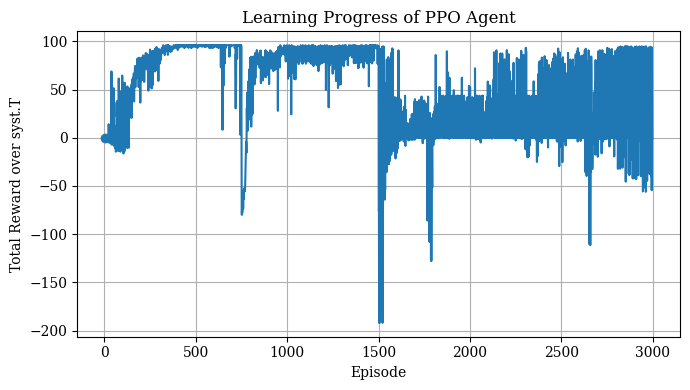

In [6]:
f_qkp = 1

# prepare agent
n_links = len(links)
n_demands = len(demands)   # assume constant across T
action_dim = n_links * n_demands # n_links

# choose state_dim produced by build_state_vector_for_time
state_vector_example = build_state_vector_for_time(state[0], links, 0, gnodes, hnodes, f_qkp=f_qkp)
state_dim = len(state_vector_example)

agent = PPOBinaryAgent(state_dim, action_dim, lr=LR)

# Training hyperparams
num_episodes = 3000
episode_len = len(syst.T)

# Track total rewards per episode
episode_rewards = []

if f_qkp:
    solution = {"a": state[0]["a"].copy()}
else:
    solution = {}

#WARM_EPISODES  = 500
DECAY_EPISODES = 300

for ep in range(num_episodes):
    # reset state & action containers
    state = [{} for _ in syst.T]
    action = [{} for _ in syst.T]
    state[0]["demands"] = demands.copy()

    if f_qkp:
        state[0]["a"] = {i: 0 for i in range(n_links)}

    # rollout buffers
    states_buf = []
    actions_buf = []
    logps_buf = []
    rewards_buf = []
    dones_buf = []
    values_buf = []

    total_reward = 0.0

    mean_kbps_rand = random.randint(1, 2)
    k_req_vals = [mean_kbps_rand] * len(syst.T) # 25600 bits/sec
    demands_space = []
    demands_space = generate_demands(gnodes, syst, mean_kbps=0.01*mean_kbps_rand, amp=0.5, noise_std=0, pattern="sinusoidal")

    MIN_DEMANDS = 1
    MAX_DEMANDS = len(demands_space)

    
    # Inside your episode loop
    # Inside your episode loop
    if ep < num_episodes / 4:
        k = 1  # Keep it simple for "Warm Up"
    elif ep < 2 * num_episodes / 4:
        k = 2  # Keep it simple for "Warm Up"
    else:
        k = random.randint(MIN_DEMANDS, MAX_DEMANDS) # Full complexity
    
    demands = random.sample(demands_space, k)
    random.shuffle(demands)

    for t in syst.T:
        # >>> NEW — build action mask before selecting action
        s_vec = build_state_vector_for_time(state[t], links, t, gnodes, hnodes, f_qkp=f_qkp)

        p_h = max(0.0, 1 - ep / DECAY_EPISODES)
        use_heuristic = (np.random.rand() < p_h)

        if ep < DECAY_EPISODES:
            if use_heuristic:
                action_vec = heuristic_policy(state[t], links, t)
            
                # IMPORTANT: still evaluate logp and value using PPO policy
                logp, value = agent.evaluate_action(s_vec, action_vec)
            else:
                action_vec, logp, value = agent.select_action(s_vec)
        else:
            action_vec, logp, value = agent.select_action(s_vec)
        
        #action_vec, logp, value = agent.select_action(s_vec)

        # # convert flat action vector to dictionary
        # action[t] = {}
        # for idx_l in range(n_links):
        #     action[t][idx_l] = int(action_vec[idx_l])

        # # Reshape flattened vector back to [demands, links]
        # action_reshaped = action_vec.reshape(n_demands, n_links)
        
        # # Convert to the dictionary format your 'online_new' expects
        # action[t] = {}
        # for d_idx in range(k): # Loop through active demands
        #     action[t][d_idx] = {}
        #     for l_idx in range(n_links):
        #         action[t][d_idx][l_idx] = int(action_reshaped[d_idx][l_idx])

        # Assuming action_vec is the flat output from agent.select_action(s_vec)
        # Reshape to (MAX_DEMANDS, N_LINKS)
        action_matrix = action_vec.reshape(-1, n_links)
        
        action[t] = {}
        # Only iterate over the demands actually present in this step
        for idx_d in range(len(demands)): 
            # Map each demand to its corresponding link-activation row
            action[t][idx_d] = {idx_l: int(action_matrix[idx_d][idx_l]) for idx_l in range(n_links)}

        #print(action_matrix)
        #print(action)

        
        # call your environment / model
        # Maximum Tx/Rx Connection
        check_tx, check_rx = 1, 1
        sum_tx, sum_rx = {}, {}

        nodes = gnodes + hnodes
        for idx_h, h in enumerate(hnodes):
            # sum_tx[idx_h] = sum(action[t][idx_l]
            #                     for idx_l, l in enumerate(links)
            #                     if  l.n1 == h
            #                    )

            # sum_rx[idx_h] = sum(action[t][idx_l]
            #                     for idx_l, l in enumerate(links)
            #                     if  l.n2 == h
            #                    )

            # Sum across all demands AND all links connected to this HAP
            sum_tx[idx_h] = sum(action_matrix[d_idx][l_idx]
                                for d_idx in range(k)
                                for l_idx, l in enumerate(links)
                                if l.n1 == h)
        
            sum_rx[idx_h] = sum(action_matrix[d_idx][l_idx]
                                for d_idx in range(k)
                                for l_idx, l in enumerate(links)
                                if l.n2 == h)
            
            check_tx = check_tx and (sum_tx[idx_h] <= h.N_TX)
            check_rx = check_rx and (sum_rx[idx_h] <= h.N_RX)

            # if not check_tx or not check_rx:
            #     # print("Violated maximum RX/TX constraints!")
            #     break

        if check_tx and check_rx:
            solution, reward_t, A_next = online_new(gnodes, hnodes, links, state, action_matrix, t, f_qkp)
        else:
            reward_t = -sum(sum_tx[idx_h] + sum_rx[idx_h] for idx_h, h in enumerate(hnodes)) / len(hnodes) / len(gnodes) / 2 #-10

        #print(f"reward_t: {reward_t}")
        if reward_t == 96:
            print(action_matrix)

        reward[t] = reward_t
        total_reward += reward_t

        # store rollout data
        states_buf.append(torch.tensor(s_vec, dtype=torch.float32))
        actions_buf.append(torch.tensor(action_vec, dtype=torch.float32))
        logps_buf.append(logp)
        values_buf.append(value)
        rewards_buf.append(torch.tensor(float(reward_t), dtype=torch.float32))
        dones_buf.append(torch.tensor(0.0))

        # step to next state
        if t + 1 < episode_len:
            if f_qkp:
                if check_tx and check_rx:
                    state[t+1]["a"] = A_next
                else:
                    state[t+1]["a"] = state[t]["a"]
            state[t+1]["demands"] = state[t]["demands"]

    # bootstrap final value
    final_s_vec = build_state_vector_for_time(state[-1], links, t, gnodes, hnodes, f_qkp=f_qkp)
    with torch.no_grad():
        _, final_value = agent.model(torch.tensor(final_s_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0))
    values_tensor = torch.stack(values_buf).to(DEVICE)
    values_tensor = torch.cat([values_tensor, final_value.view(1)])   # shape [T+1]

    rewards_tensor = torch.stack(rewards_buf).to(DEVICE)
    dones_tensor = torch.stack(dones_buf).to(DEVICE)

    advantages, returns = agent.compute_gae(rewards_tensor, values_tensor, dones_tensor)

    # prepare PPO update batches
    states_b = torch.stack(states_buf)
    actions_b = torch.stack(actions_buf)
    old_logps_b = torch.stack(logps_buf).to(DEVICE)
    returns_b = returns.detach()
    adv_b = advantages.detach()

    # >>> adaptive entropy scheduling (slower exploration over time)
    entropy_coef = max(entropy_coef * ENTROPY_DECAY, ENTROPY_COEF_MIN)

    agent.update(states_b, actions_b, old_logps_b, returns_b, adv_b, entropy_coef)  # >>> CHANGE

    # store total reward for this episode
    episode_rewards.append(total_reward)

    # print progress
    print(f"Episode {ep+1}/{num_episodes}, total reward: {total_reward:.3f}, entropy_coef: {entropy_coef:.4f}, demands: {len(demands)}")

# === Plot learning curve ===
plt.figure(figsize=(7,4))
plt.plot(range(1, num_episodes+1), episode_rewards, marker='o', markevery=num_episodes/10, linewidth=1.5)
plt.xlabel("Episode")
plt.ylabel("Total Reward over syst.T")
plt.title("Learning Progress of PPO Agent")
plt.grid(True)
plt.tight_layout()
plt.show()

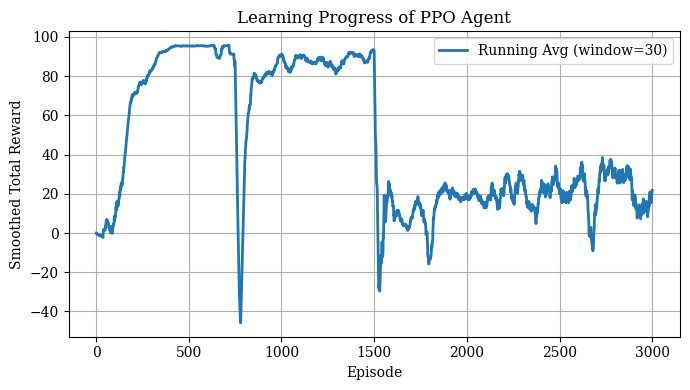

In [7]:
# === Plot learning curve with running average ===
window = 30                     # moving average window (change as desired)
running_avg = []

for i in range(len(episode_rewards)):
    start = max(0, i - window + 1)
    running_avg.append(np.mean(episode_rewards[start:i+1]))

plt.figure(figsize=(7,4))
plt.plot(range(1, num_episodes+1), running_avg, linewidth=2, label=f"Running Avg (window={window})")
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Learning Progress of PPO Agent")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

## Testing the Agent

In [8]:
def test_agent(agent, syst, links, gnodes, hnodes, num_test_episodes=50, f_qkp=True):
    agent.model.eval()  # Set network to evaluation mode
    test_rewards = []
    success_counts = 0

    print(f"--- Starting Evaluation for {num_test_episodes} Episodes ---")

    for ep in range(num_test_episodes):
        # Reset environment
        mean_kbps_rand = random.randint(2, 3)
        demands_space = generate_demands(gnodes, syst, mean_kbps=0.1*mean_kbps_rand, amp=0.5, noise_std=0, pattern="sinusoidal")

        MIN_DEMANDS = 1
        MAX_DEMANDS = len(demands_space)
        k = random.randint(MIN_DEMANDS, MAX_DEMANDS)
        demands = random.sample(demands_space, k)
        random.shuffle(demands)
        
        state = [{} for _ in syst.T]
        state[0]["demands"] = demands #generate_demands(gnodes, syst, mean_kbps=1.5, pattern="sinusoidal") # Use unseen noise/pattern
        if f_qkp:
            state[0]["a"] = {i: 0 for i in range(len(links))} # Start with empty pool

        ep_reward = 0
        
        for t in syst.T:
            s_vec = build_state_vector_for_time(state[t], links, t, gnodes, hnodes, f_qkp=f_qkp)
            s_tensor = torch.tensor(s_vec, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                # Get action deterministically (most likely action, no sampling)
                # Note: You may need a method like agent.get_deterministic_action() 
                # or manually take the argmax/mean of the policy output.
                action_vec, _, _ = agent.select_action(s_vec) 

            # Environment Step (Logic from your training loop)
            # [Insert your constraint check: check_tx, check_rx]
            # [Insert your env step: online_new]
            check_tx, check_rx = 1, 1
            sum_tx, sum_rx = {}, {}
        
            nodes = gnodes + hnodes
            for idx_h, h in enumerate(hnodes):
                sum_tx[idx_h] = sum(action[t][idx_l]
                                    for idx_l, l in enumerate(links)
                                    if  l.n1 == h
                                   )
    
                sum_rx[idx_h] = sum(action[t][idx_l]
                                    for idx_l, l in enumerate(links)
                                    if  l.n2 == h
                                   )
                
                check_tx = check_tx and (sum_tx[idx_h] <= h.N_TX)
                check_rx = check_rx and (sum_rx[idx_h] <= h.N_RX)
    
            if check_tx and check_rx:
                solution, reward_t, A_next = online_new(gnodes, hnodes, links, state, action, t, f_qkp)
            else:
                reward_t = -sum(sum_tx[idx_h] + sum_rx[idx_h] for idx_h, h in enumerate(hnodes)) / len(hnodes) / len(gnodes) / 2 #-10
            
            # Record results
            ep_reward += reward_t

            # Update next state
            if t + 1 < len(syst.T):
                state[t+1]["a"] = A_next if (check_tx and check_rx) else state[t]["a"]
                state[t+1]["demands"] = state[t]["demands"]

        test_rewards.append(ep_reward)
        print(f"Test Episode {ep+1}: Total Reward = {ep_reward:.2f}, demands: {len(demands)}")

    avg_reward = sum(test_rewards) / num_test_episodes
    print(f"--- Evaluation Complete. Average Reward: {avg_reward:.2f} ---")
    return test_rewards

# Run the test
results = test_agent(agent, syst, links, gnodes, hnodes, num_test_episodes=200, f_qkp=f_qkp)

--- Starting Evaluation for 200 Episodes ---


TypeError: unsupported operand type(s) for +: 'int' and 'dict'

##### 